In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2, DenseNet201, ResNet152

import matplotlib.pyplot as plt


In [2]:
def train_val_generators(TRAINING_DIR, TESTING_DIR, VALIDATION_DIR):
    train_datagen = ImageDataGenerator(rescale=1./255,
                                      rotation_range=180,
                                      width_shift_range=0.2,
                                      height_shift_range=0.2,
                                      shear_range = 0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      fill_mode='nearest')
    train_generator = train_datagen.flow_from_directory(directory=TRAINING_DIR,
                                                      class_mode='categorical',
                                                      target_size=(100, 100))
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(directory=TESTING_DIR,
                                                                class_mode='categorical',
                                                                target_size=(100, 100))
    validation_datagen = ImageDataGenerator(rescale = 1./255)
    validation_generator = validation_datagen.flow_from_directory(directory=VALIDATION_DIR,
                                                                 class_mode = 'categorical',
                                                                 target_size=(100, 100))
    return train_generator, test_generator, validation_generator


In [3]:
training = "plants-classification/train"
testing = "plants-classification/test"
validation = "plants-classification/val"
train_generator, test_generator, validation_generator = train_val_generators(training, testing, validation)

Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.


In [4]:
x_train = []
c = 0
for feature, label in train_generator:
    x_train.append(np.array(feature))
    c += 1
    if c == 1:
        break

x_train = np.array(x_train)
print(x_train.shape)
x_train = np.reshape(x_train, (32, 100, 100, 3))
print(x_train.shape)

(1, 32, 100, 100, 3)
(32, 100, 100, 3)


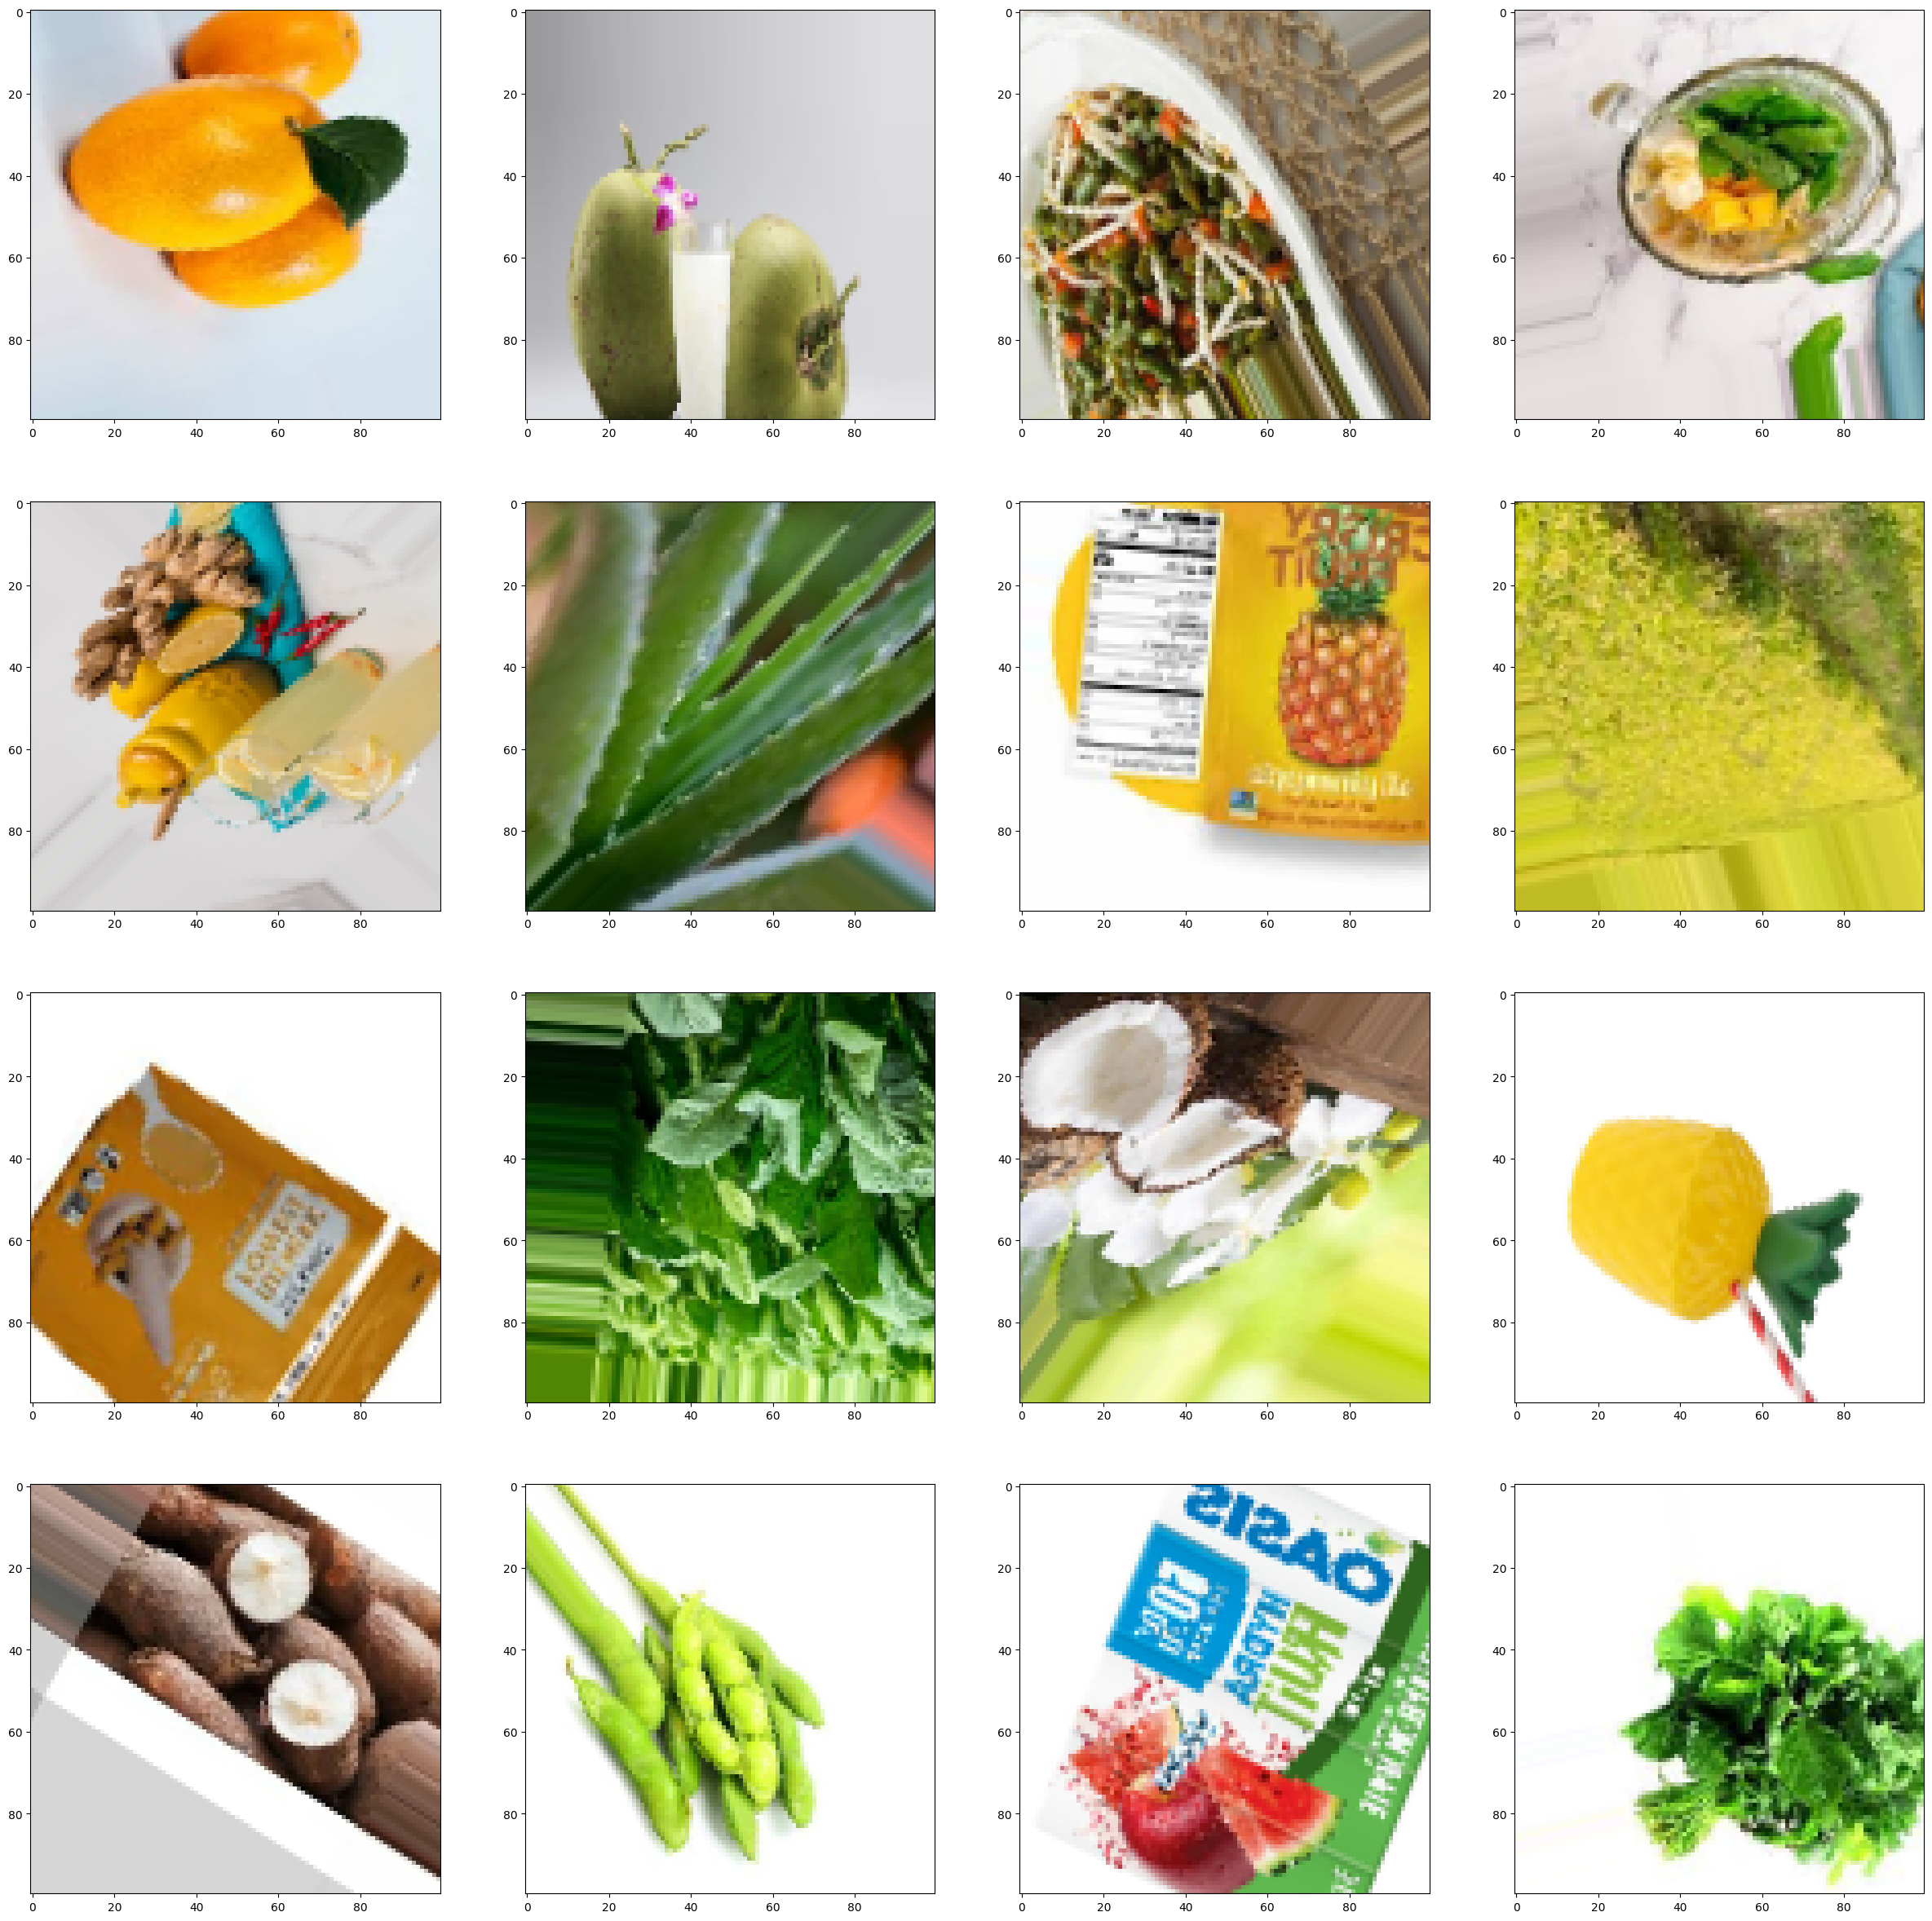

In [5]:
fig, ax = plt.subplots(4, 4, figsize=(30, 30))
for i in range(0, 16):
    ax[int(i / 4), (i % 4)].imshow(x_train[i])

In [6]:
def create_model():
    model = models.Sequential([
      layers.Conv2D(32, (2,2), activation='relu', input_shape=(100, 100, 3)),
      layers.MaxPooling2D(2,2),
      layers.Conv2D(64, (2,2), activation='relu'),
      layers.MaxPooling2D(2,2),
      layers.Conv2D(64, (3,3), activation='relu'),
      layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
      layers.MaxPooling2D(2,2),
      # Flatten the results to feed into a DNN
      layers.Flatten(),
      # 512 neuron hidden layer
        layers.Dropout(0.1),
      layers.Dense(512, activation='relu'),
        layers.Dropout(0.1),
      layers.Dense(30, activation='softmax')
    ])

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model

In [8]:
model = create_model()
epochs = 5
history = model.fit(train_generator,
                    epochs=epochs,
                    verbose=1,
                    validation_data=test_generator)

Epoch 1/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 261s 394ms/step - accuracy: 0.1696 - loss: 2.8053 - val_accuracy: 0.2762 - val_loss: 2.3790
Epoch 2/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 307s 467ms/step - accuracy: 0.2756 - loss: 2.3943 - val_accuracy: 0.3098 - val_loss: 2.2814
Epoch 3/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 157s 239ms/step - accuracy: 0.3243 - loss: 2.2353 - val_accuracy: 0.3653 - val_loss: 2.1062
Epoch 4/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 157s 240ms/step - accuracy: 0.3546 - loss: 2.1376 - val_accuracy: 0.3685 - val_loss: 2.1298
Epoch 5/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 165s 251ms/step - accuracy: 0.3820 - loss: 2.0502 - val_accuracy: 0.3948 - val_loss: 2.0251


In [9]:
def plot_accuracies(history):
    acc=history.history['accuracy']
    val_acc=history.history['val_accuracy']
    loss=history.history['loss']
    val_loss=history.history['val_loss']

    epochs=range(len(acc)) # Get number of epochs

    #------------------------------------------------
    # Plot training and validation accuracy per epoch
    #------------------------------------------------
    plt.plot(epochs, acc, 'r')
    plt.plot(epochs, val_acc, 'b')
    plt.title('Training and testing accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(['Training', 'testing'])
    plt.show()
    print("")

    plt.plot(epochs, loss, 'r')
    plt.plot(epochs, val_loss, 'b')
    plt.title('Training and testing loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(['Training', 'testing'])
    plt.show()

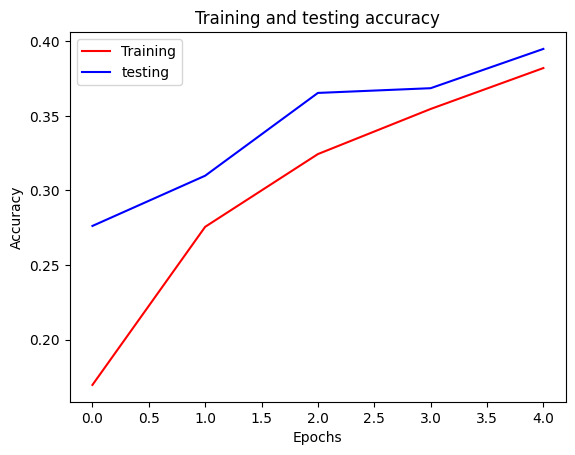

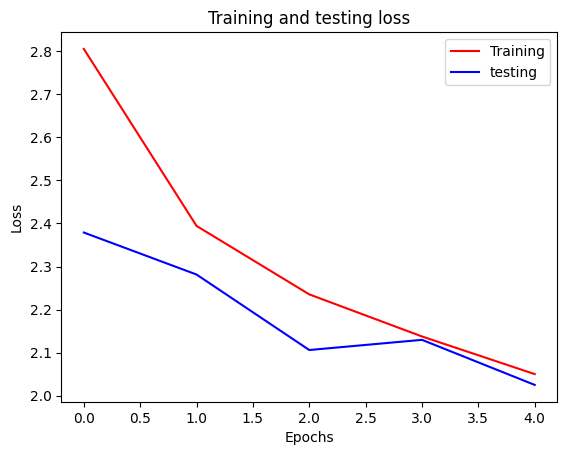

In [10]:
plot_accuracies(history)

In [11]:
resnet_model = models.Sequential()

pretrained_models = [
    InceptionResNetV2(include_top = False,input_shape = (100, 100, 3),pooling='max', classes = 30,weights = 'imagenet', classifier_activation="softmax",),
    DenseNet201(include_top=False,weights="imagenet",input_shape=(100, 100, 3),pooling='max',classes=30,classifier_activation="softmax"),
    ResNet152(include_top=False, weights="imagenet",input_shape=(100, 100, 3),pooling='max',classes=30, classifier_activation="softmax"),
]

final_models = []

for model in pretrained_models:
    for layer in model.layers:
        layer.trainable = False
    m = models.Sequential()   
    m.add(model)
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation = 'relu'))
    m.add(layers.Dense(30, activation = "softmax"))
    final_models.append(m)


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of ee4c566cf9a93f14d82f913c2dc6dd0c so we will re-download the data.
234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 37s 0us/step


In [12]:
for model in final_models:
    print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 1536)           │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,139,070 (210.34 MB)

 Trainable params: 802,334 (3.06 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152 (Functional)          │ (None, 2048)           │    58,370,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,435,422 (226.73 MB)

 Trainable params: 1,064,478 (4.06 MB)

 Non-trainable params: 58,370,944 (222.67 MB)

None


In [13]:
for model in final_models:
    model.compile(optimizer = 'adam', loss='categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
for model in final_models:
    history = model.fit(train_generator,
                    epochs=10,
                    verbose=1,
                    validation_data=test_generator)
    plot_accuracies(history)

In [20]:
class_indices = train_generator.class_indices
class_names = [None] * len(class_indices)
for name, idx in class_indices.items():
    class_names[idx] = name
print(class_names)

['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']


Using model: <Sequential name=sequential_5, built=True>
train_generator.class_indices: {'aloevera': 0, 'banana': 1, 'bilimbi': 2, 'cantaloupe': 3, 'cassava': 4, 'coconut': 5, 'corn': 6, 'cucumber': 7, 'curcuma': 8, 'eggplant': 9, 'galangal': 10, 'ginger': 11, 'guava': 12, 'kale': 13, 'longbeans': 14, 'mango': 15, 'melon': 16, 'orange': 17, 'paddy': 18, 'papaya': 19, 'peperchili': 20, 'pineapple': 21, 'pomelo': 22, 'shallot': 23, 'soybeans': 24, 'spinach': 25, 'sweetpotatoes': 26, 'tobacco': 27, 'waterapple': 28, 'watermelon': 29}
class_names (len): 30
class_names from generator (ordered): ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']


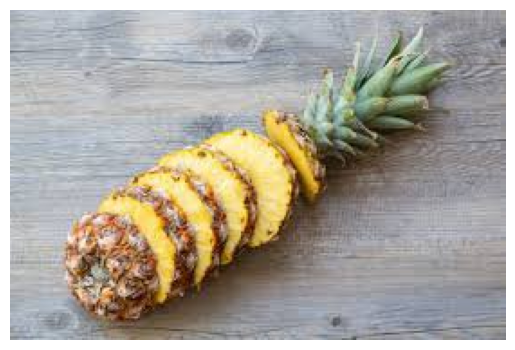

raw prediction vector (first 10): [5.2839001e-05 6.4325541e-06 1.3768749e-06 2.7508900e-04 2.0677357e-03
 9.0522744e-06 2.8763253e-08 1.3658780e-05 4.2275035e-05 8.1775179e-03]
sum softmax: 1.0
Top 5 (idx, name, confidence%):
21 pineapple 96.23%
11 ginger 1.32%
9 eggplant 0.82%
26 sweetpotatoes 0.55%
10 galangal 0.32%
predict_plant mapping: pineapple


In [27]:
# Diagnostic cell — run this
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Select model to test: 'simple' or index 0/1/2 for pretrained heads
MODEL_CHOICE = 'simple'   # or 0,1,2

# select model object
try:
    if MODEL_CHOICE == 'simple':
        MODEL_TO_USE = model
    else:
        MODEL_TO_USE = final_models[int(MODEL_CHOICE)]
except Exception:
    MODEL_TO_USE = model
print("Using model:", MODEL_TO_USE)

# Confirm class index mapping from generator
print("train_generator.class_indices:", train_generator.class_indices)

# Ensure class_names matches the generator mapping
try:
    print("class_names (len):", len(class_names))
except NameError:
    print("class_names not defined")

# Show class_names built from generator (recommended)
ci = train_generator.class_indices
names_from_generator = [None]*len(ci)
for name, idx in ci.items():
    names_from_generator[idx] = name
print("class_names from generator (ordered):", names_from_generator)

# Load and display the test image
IMAGE_PATH = 'plants-classification/test/pineapple/pineapple800.jpg'  # change path if needed
img = Image.open(IMAGE_PATH).convert('RGB')
plt.imshow(img); plt.axis('off'); plt.show()

# Preprocess exactly like training
from tensorflow.keras.preprocessing import image as keras_image
x = keras_image.img_to_array(img.resize((100,100))) / 255.0
x = np.expand_dims(x, axis=0)

# Predict and show raw scores
pred = MODEL_TO_USE.predict(x, verbose=0)[0]
print("raw prediction vector (first 10):", pred[:10])
print("sum softmax:", pred.sum())
top_idx = np.argsort(pred)[-5:][::-1]
print("Top 5 (idx, name, confidence%):")
for i in top_idx:
    name = names_from_generator[i] if i < len(names_from_generator) else f"idx_{i}"
    print(i, name, f"{pred[i]*100:.2f}%")

# Quick check: predicted name via current class_names variable (if present)
try:
    print("predict_plant mapping:", class_names[np.argmax(pred)])
except Exception:
    print("class_names unavailable or mismatched; use names_from_generator instead.")

## Flow Diagram for Plant Identification Module

```mermaid
graph TD
    A[Start: Plant Identification Module] --> B[Import Libraries: NumPy, TensorFlow, Keras, PIL, Matplotlib]
    B --> C[Define Data Generators: Create train/test/val generators with augmentation]
    C --> D[Visualize Sample Data: Display batch of training images]
    D --> E{Model Choice}
    E -->|Simple CNN| F[Create Custom CNN Model: Conv2D, MaxPooling, Dense layers]
    E -->|Pre-trained| G[Load Pre-trained Models: InceptionResNetV2, DenseNet201, ResNet152]
    F --> H[Compile Model: Adam optimizer, categorical cross-entropy loss]
    G --> I[Freeze Base Layers, Add Custom Head: Flatten, Dense(512), Dense(30)]
    I --> H
    H --> J[Train Model: Fit on train_generator, validate on test_generator]
    J --> K[Plot Training History: Accuracy and Loss curves]
    K --> L[Extract Class Names: Map indices to plant names]
    L --> M[Load Test Image: Open and display image]
    M --> N[Preprocess Image: Resize to 100x100, normalize, expand dims]
    N --> O[Predict Probabilities: Run model.predict()]
    O --> P[Display Top Predictions: Class names and confidence scores]
    P --> Q[End]
```